In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import joblib
import os

os.makedirs('../models', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('../data/Personal_Finance_Tracker.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3000, 25)


,date,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,...,discretionary_spending,essential_spending,income_type,rent_or_mortgage,category,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met
0,1/1/2019,1584,3119.58,3212.07,0.38,3676.11,inflation,721,0.56,125.77,...,857.55,1910.85,Freelance,1501.65,Investments,Positive,8.3,Low,0.00,0
1,1/31/2019,1045,3262.44,3732.81,0.10,2607.17,inflation,670,0.42,454.19,...,534.51,3165.20,Salary,1603.17,Investments,Positive,22.6,Low,0.00,0
2,3/2/2019,1756,2931.20,3335.58,0.15,3004.14,inflation,691,0.24,971.82,...,353.67,1504.56,Freelance,1097.82,Healthcare,Positive,58.8,Low,0.00,0
3,4/1/2019,1724,3506.79,2327.59,0.17,3346.97,normal,717,0.16,482.76,...,594.08,1450.72,Freelance,1155.64,Groceries,Positive,74.5,Low,1179.20,0
4,5/1/2019,1600,4606.87,2182.58,0.34,2670.09,inflation,795,0.25,263.74,...,556.86,1000.00,Salary,1170.86,Utilities,Negative,38.7,High,2424.29,0


In [3]:
features = ['monthly_income', 'savings_rate', 'debt_to_income_ratio']

user_profile = df.groupby('user_id')[features].mean().reset_index()
print(f'Unique users: {len(user_profile)}')
user_profile.describe()

Unique users: 944


,user_id,monthly_income,savings_rate,debt_to_income_ratio
count,944.000000,944.000000,944.000000,944.000000
mean,1502.115466,4021.947497,0.225150,0.350224
std,289.473480,661.862703,0.067258,0.091786
min,1000.000000,1358.550000,0.050000,0.110000
25%,1251.750000,3630.684167,0.180000,0.289167
50%,1502.500000,4002.358000,0.225000,0.350000
75%,1751.250000,4406.876750,0.266667,0.410000
max,1999.000000,6768.220000,0.400000,0.600000


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(user_profile[features])
print('Features scaled.')

Features scaled.


d:\Save\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\Save\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\Save\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\Save\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You c

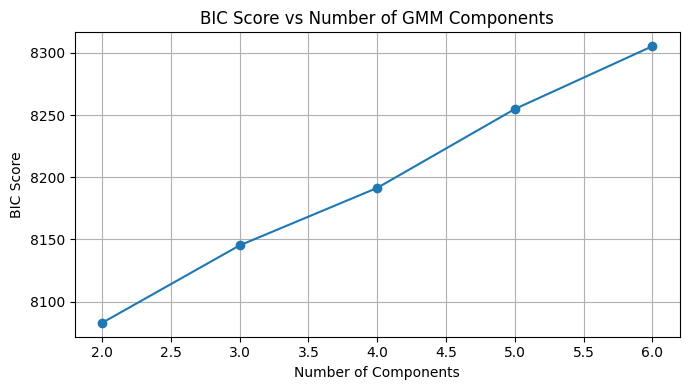

Optimal components: 2


In [6]:
bic_scores = []
n_range = range(2, 7)

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

plt.figure(figsize=(7, 4))
plt.plot(n_range, bic_scores, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('BIC Score')
plt.title('BIC Score vs Number of GMM Components')
plt.grid(True)
plt.tight_layout()
plt.show()

best_n = n_range[np.argmin(bic_scores)]
print(f'Optimal components: {best_n}')

In [7]:
N_COMPONENTS = 3  # override if needed based on BIC

gmm = GaussianMixture(n_components=N_COMPONENTS, random_state=42)
user_profile['cluster'] = gmm.fit_predict(X_scaled)

# Label clusters by avg income (low → high)
cluster_income = user_profile.groupby('cluster')['monthly_income'].mean().sort_values()
label_map = {
    cluster_income.index[0]: 'Low-Income Stressed',
    cluster_income.index[1]: 'Middle Balanced',
    cluster_income.index[2]: 'High-Income Stable'
}
user_profile['segment'] = user_profile['cluster'].map(label_map)

print('Segment distribution:')
print(user_profile['segment'].value_counts())

Segment distribution:
segment
Low-Income Stressed    540
Middle Balanced        244
High-Income Stable     160
Name: count, dtype: int64


d:\Save\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


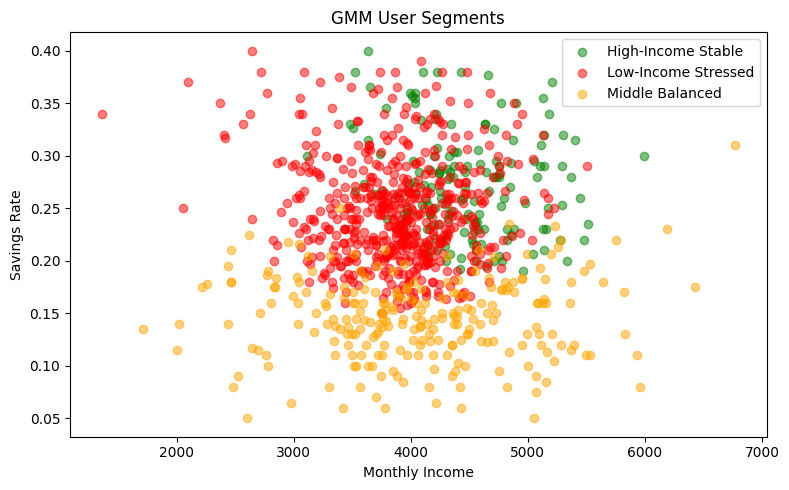

In [8]:
plt.figure(figsize=(8, 5))
colors = {'Low-Income Stressed': 'red', 'Middle Balanced': 'orange', 'High-Income Stable': 'green'}
for seg, grp in user_profile.groupby('segment'):
    plt.scatter(grp['monthly_income'], grp['savings_rate'],
                label=seg, alpha=0.5, color=colors[seg])
plt.xlabel('Monthly Income')
plt.ylabel('Savings Rate')
plt.title('GMM User Segments')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
joblib.dump(gmm, '../models/gmm_model.pkl')
joblib.dump(scaler, '../models/gmm_scaler.pkl')
joblib.dump(label_map, '../models/gmm_label_map.pkl')
user_profile[['user_id', 'segment']].to_csv('../models/user_segments.csv', index=False)

print('All GMM artifacts saved to models/')

All GMM artifacts saved to models/
